# TP DSP - Grupo 5: Filtrado e Identificación de Sistemas

## Introducción

Un analizador de doble canal analiza simultáneamente la entrada y salida de un sistema 
para caracterizarlo en frecuencia. La respuesta en frecuencia H(ω) se obtiene como:

$$H(\omega) = \frac{Y(\omega)}{X(\omega)}$$

donde Y(ω) y X(ω) son las transformadas de Fourier de la salida y entrada respectivamente.

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from funciones import *
import time
import timeit


%matplotlib inline

## Parte 1: Herramientas de análisis

### 1. Generación y gráfico de señales

A continuación se presentan las herramientas destinadas a la generación de señales y su representación visual, mediante ejemplos.

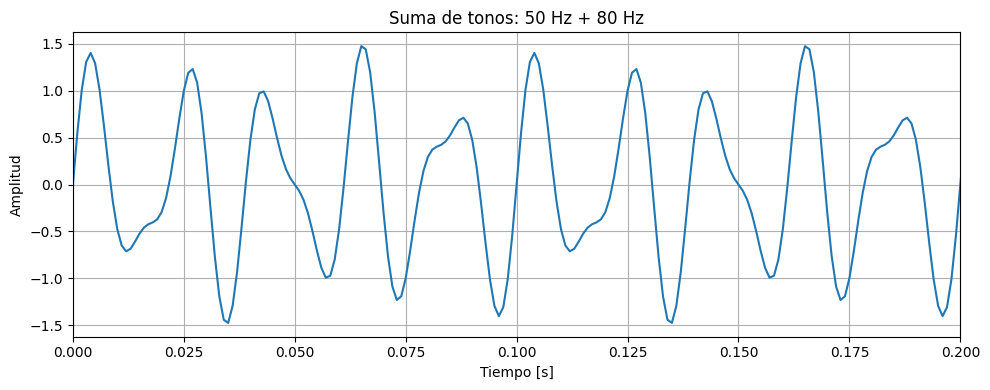

In [81]:
# Parámetros
fs = 1000       # frecuencia de muestreo: 1000 Hz
duracion = 1    # 1 segundo

senal = generar_suma_tonos(
    frecuencias=[50, 80],
    amplitudes=[1, 0.5],
    fs=fs,
    duracion=duracion
)

graficar_senales(senal, fs=fs, titulo="Suma de tonos: 50 Hz + 80 Hz", xlim=(0, 0.2))

A continuación se grafica el espectro de dicha señal mediante una función que utiliza la herramienta de la DFT optimizada mediante el algoritmo de la FFT. Se descarta la mitad del espectro graficado, pues aquí es donde se ubica el aliasing visual producto de las bases de la transformada.

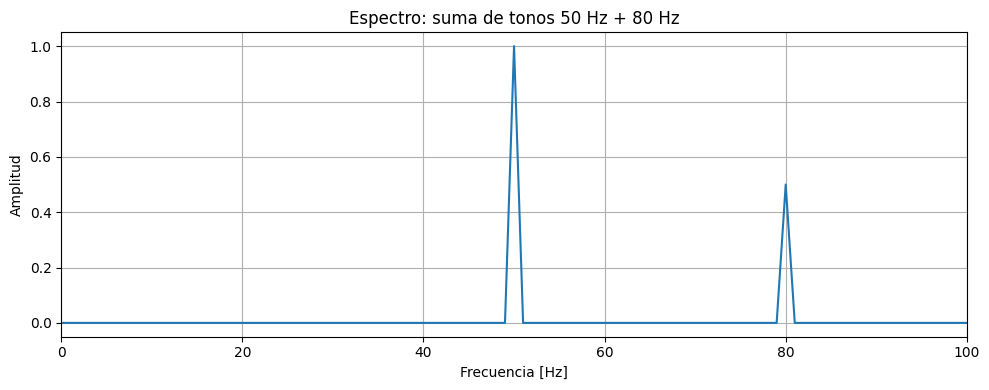

In [82]:
# Graficamos el espectro de la misma señal
graficar_espectros(senal, fs=fs, titulo="Espectro: suma de tonos 50 Hz + 80 Hz", xlim=(0, 100))

Los dos picos en el espectro corresponden exactamente a las frecuencias de los tonos 
generados (50 Hz y 80 Hz), con amplitudes proporcionales a las indicadas (1 y 0.5 
respectivamente).

### 2. Señales con ruido blanco
#### Suma de tonos puros

Aquí se añade ruido a la señal generada:

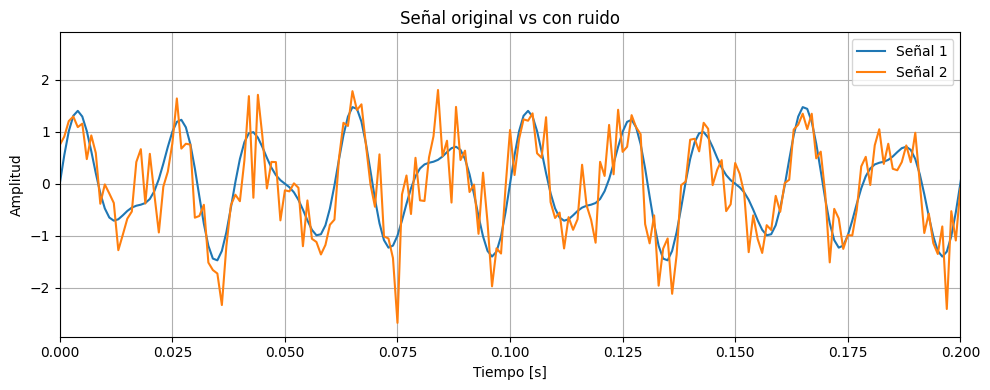

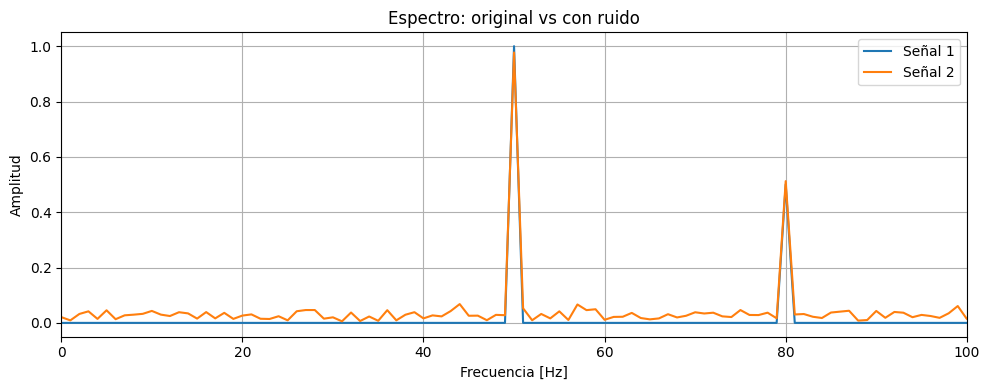

In [83]:
tonos_con_ruido, ruido = agregar_ruido_blanco(senal, amplitud=0.5)

graficar_senales([senal, tonos_con_ruido], fs=fs, titulo="Señal original vs con ruido", xlim=(0, 0.2))

graficar_espectros([senal, tonos_con_ruido], fs=fs, titulo="Espectro: original vs con ruido", xlim=(0, 100))

### Observación

Al agregar ruido blanco, en el dominio temporal la señal se ve "sucia" pero todavía 
se reconoce la forma original. En el espectro, el ruido 
blanco distribuye energía en **todas las frecuencias** de manera uniforme, lo que se 
manifiesta como un "piso" de perturbaciones a lo largo de todo el espectro, en lugar 
de los dos picos limpios de la señal original.

#### Señal musical

Se generó una melodia a la cual se le fueron agregando distintas amplitudes de ruido blanco

In [ ]:
fs= 44100
notas = [523.25, 659.25, 783.99] # Do, Mi, Sol
duraciones = [00.2, 0.2, 0.2]

melodia = generar_melodia(notas, duraciones, fs)

amplitudes_ruido = [0.05, 0.1, 0.2]  # Tres niveles de ruido

for amp in amplitudes_ruido:

    senal_con_ruido, ruido = agregar_ruido_blanco(melodia, amp)

    generate_wav(senal_con_ruido,f"melodia_ruido_{amp}.wav",fs )
    generate_wav(ruido,f"solo_ruido_{amp}.wav",fs)

### 3. Filtros y respuesta al impulso

Se analizan los tres filtros requeridos: media móvil, peine y FIR. Cabe aclarar, que todos estos filtros son FIR, pero se lo llama así al que se realizó con la ventana de Hamming.

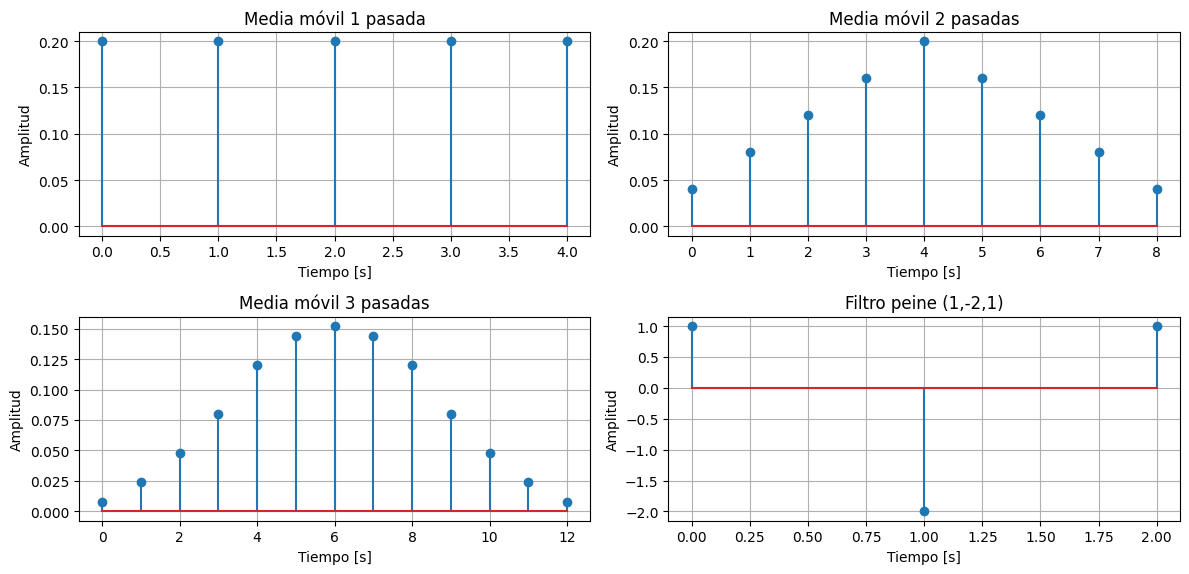

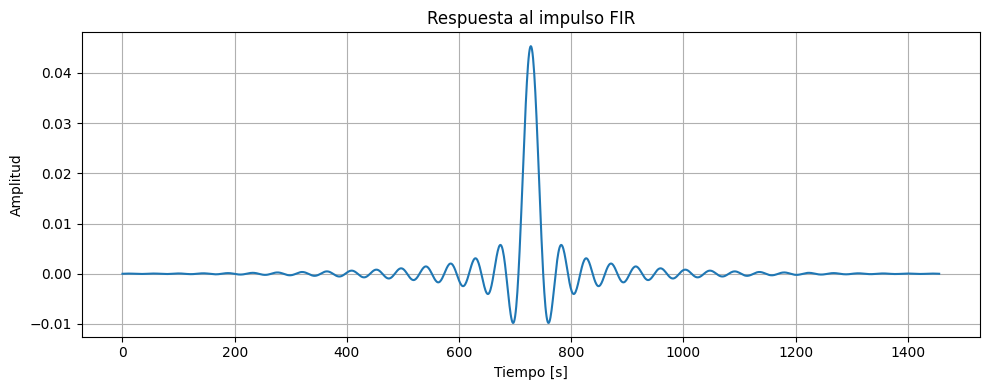

In [85]:
# se generan las respuestas al impulso de cada filtro

h_1p = filtro_media_movil(M=5)
h_2p = np.convolve(h_1p, h_1p)
h_3p = np.convolve(h_2p, h_1p)

h_peine = filtro_peine(b0=1, b1=-2, b2=1)  # un ejemplo de filtro peine

h_fir = cargar_filtro_fir("fir_hamming_1000Hz.npy")

graficar_senales(
    [
        h_1p,
        h_2p,
        h_3p,
        h_peine,
    ],
    subplots=True,
    stem=True,
    ncols=2,
    titles=[
        "Media móvil 1 pasada",
        "Media móvil 2 pasadas",
        "Media móvil 3 pasadas",
        "Filtro peine (1,-2,1)"
    ]
)


graficar_senales(
    h_fir,
    titulo="Respuesta al impulso FIR",
    stem=False
)

### 4. Caracterización en frecuencia de los filtros (módulo y fase)

Para analizar el comportamiento de cada filtro en frecuencia con las funciones armadas, se calcula su respuesta 
en frecuencia H(ω) aplicando el filtro a un impulso y luego calculando la FFT, con la frecuencia normalizada la frecuencia dividida por la frecuencia de muestreo, logrando que de esta manera se pueda caracterizar el filtro sin depender de una `fs`. Se usa un impulso de 2048 muestras debido a que el filtro FIR posee casi 1500 coeficientes, y con dicho `N` se busca llegar a la potencia en base 2 más cercana.

Además, se hace slicing a los resultados de las señales filtradas para eliminar el transitorio de salida, que ocurre luego de que la señal terminó.

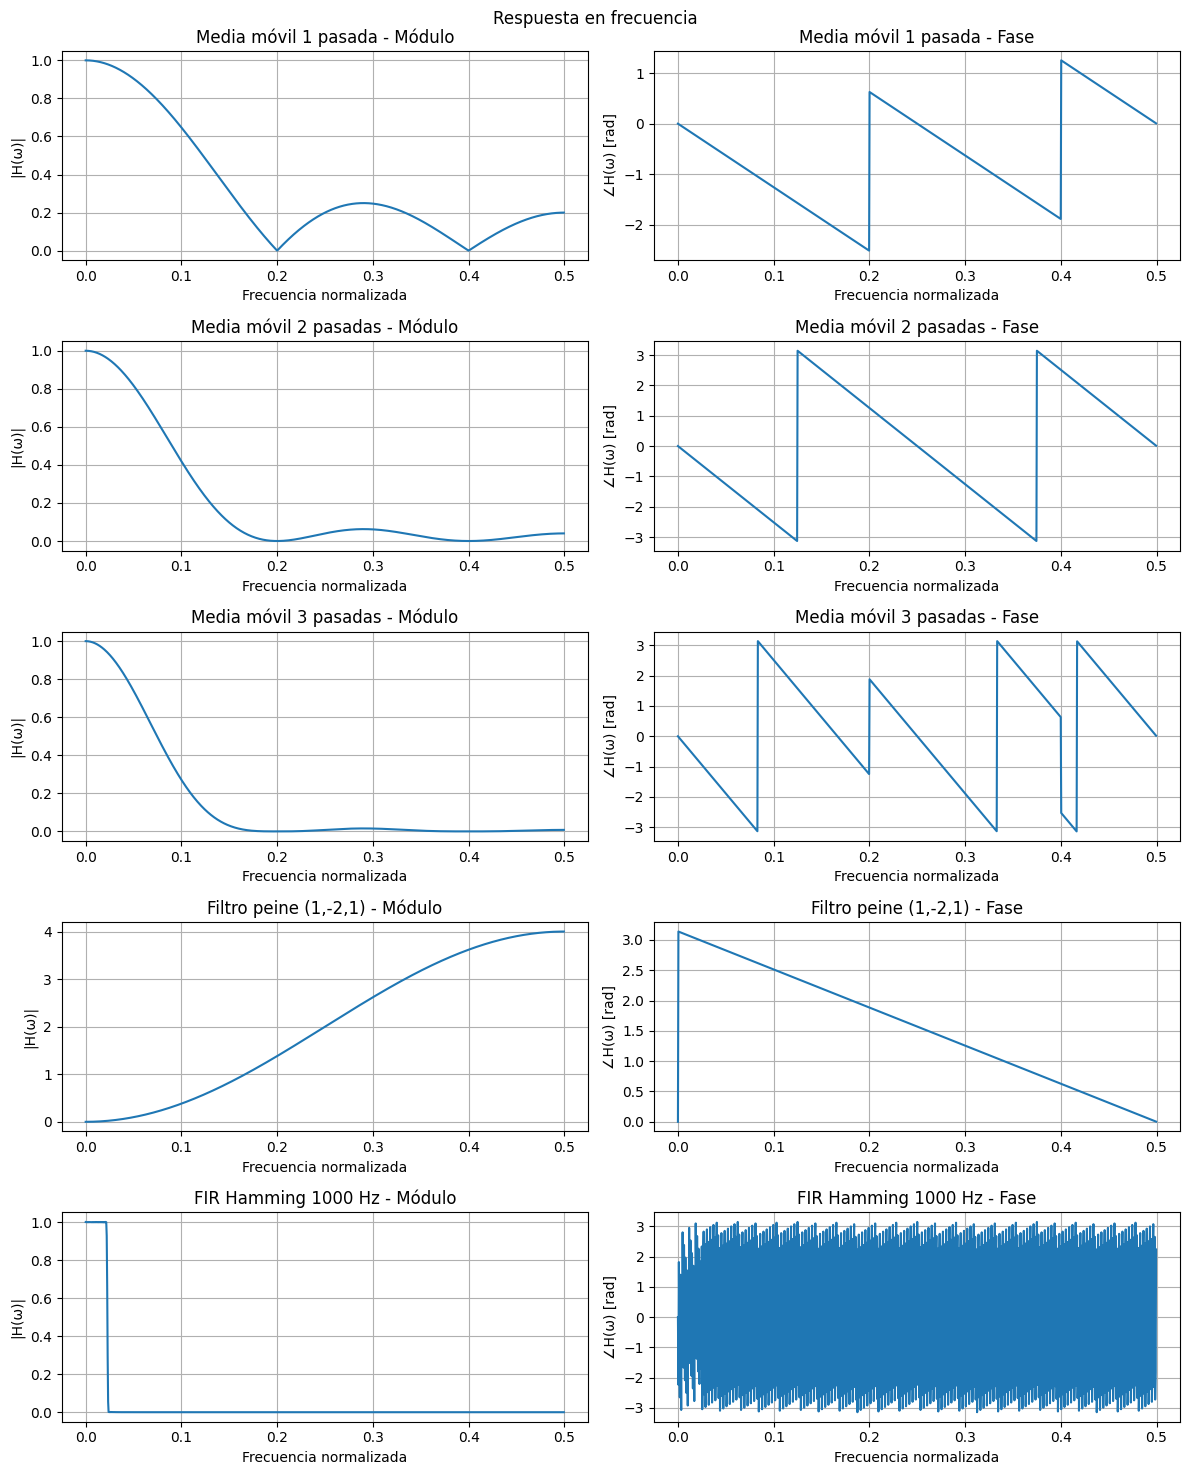

In [86]:
# Creamos impulso
N = 2048
impulso = np.zeros(N)
impulso[0] = 1

# Salidas
y_1p = filtrar_convolucion(impulso, h_1p)[:N]
y_2p = filtrar_convolucion(impulso, h_2p)[:N]
y_3p = filtrar_convolucion(impulso, h_3p)[:N]
y_peine = filtrar_convolucion(impulso, h_peine)[:N]
y_fir = filtrar_convolucion(impulso, h_fir)[:N]

# H(w)
H_1p, freqs = calcular_H(impulso, y_1p)
H_2p, _ = calcular_H(impulso, y_2p)
H_3p, _ = calcular_H(impulso, y_3p)
H_peine, _ = calcular_H(impulso, y_peine)
H_fir, _ = calcular_H(impulso, y_fir)

# Graficar módulo y fase
graficar_H(
    [
        H_1p,
        H_2p,
        H_3p,
        H_peine,
        H_fir
    ],
    [
        freqs,
        freqs,
        freqs,
        freqs,
        freqs
    ],
    subplots=True,
    titles=[
        "Media móvil 1 pasada",
        "Media móvil 2 pasadas",
        "Media móvil 3 pasadas",
        "Filtro peine (1,-2,1)",
        "FIR Hamming 1000 Hz"
    ]
)

### Observación: caracterización en frecuencia de los filtros

#### Media móvil — efecto de las pasadas

La respuesta al impulso de una sola pasada es un pulso rectangular de ancho M. Al aumentar el número de pasadas, la convolución sucesiva de ese pulso consigo mismo produce formas cada vez más suaves: triangular con 2 pasadas, y acampanada (aproximación a una Gaussiana) con 3. Esto se refleja directamente en la respuesta en frecuencia:

- **Módulo**: con más pasadas, el lóbulo principal se mantiene centrado en DC pero los lóbulos secundarios de la sinc se atenúan progresivamente. La respuesta se aproxima a la de un filtro Gaussiano ideal, que no tiene lóbulos laterales. El filtro sigue siendo **pasa-bajos** en todos los casos.
- **Fase**: los tres filtros presentan fase lineal, propiedad característica de todos los filtros FIR simétricos. Esto implica retardo de grupo constante: todas las frecuencias se retrasan la misma cantidad de tiempo, preservando la forma de la señal filtrada. Se observan saltos repentinos en la fase que coinciden con el módulo valiendo 0, pero estos ocurren en frecuencias donde la señal ya no tiene mas energía porque ya se filtró, por lo tanto no es significativo su análisis.

#### Filtro peine [1, −2, 1]

El comportamiento del filtro peine es opuesto al de la media móvil:

- **Módulo**: la ganancia es cero en DC (frecuencia normalizada = 0) y máxima en la frecuencia de Nyquist (0.5). Esto se verifica directamente: la suma de coeficientes es 1 − 2 + 1 = 0, lo que garantiza atenuación total de la componente continua. Se trata de un filtro **pasa-altos** que resalta los cambios rápidos entre muestras consecutivas.
- **Fase**: también lineal, al ser un FIR simétrico.

#### Filtro de respuesta al impulso finita

A diferencia de la media móvil y el filtro peine (que son filtros de coeficientes simples y fijos), el diseño de filtros FIR mediante el método de ventaneo permite alcanzar una alta selectividad:

- **Módulo:** El filtro diseñado mediante ventana de Hamming presenta un comportamiento pasa-bajos. El ventaneo de la respuesta ideal reduce significativamente los lóbulos secundarios en la banda de rechazo respecto de un truncado rectangular, aunque introduce un leve ensanchamiento de la banda de transición.
- **Fase:** Debido a la simetría de sus coeficientes temporales ($h[n] = h[M-n]$), el filtro presenta fase lineal dentro de la región donde el módulo posee amplitud significativa. Esto implica retardo de grupo aproximadamente constante y preservación de la forma temporal de las componentes que atraviesan el filtro. En regiones donde la ganancia del filtro tiende a cero, la representación de fase pierde significado práctico y puede presentar discontinuidades numéricas.

#### Comparación entre filtros

| Filtro | Tipo | Ganancia en DC | Lóbulos laterales |
|---|---|---|---|
| Media móvil 1 pasada | Pasa-bajos | 1 | Presentes (sinc) |
| Media móvil 2 pasadas | Pasa-bajos | 1 | Reducidos |
| Media móvil 3 pasadas | Pasa-bajos | 1 | Muy reducidos (Gaussiana) |
| Peine [1,−2,1] | Pasa-altos | 0 | N/A |
| FIR | Pasa-bajos | 0 | Ultra reducidos|

### 5. Filtrado de suma de tonos con ruido (con media móvil)

Se procede al filtrado de media móvil de los tonos con ruido por medio de la convolucion circular, y tambien por medio de la transformada, para evaluar las diferencias entre ambos métodos.

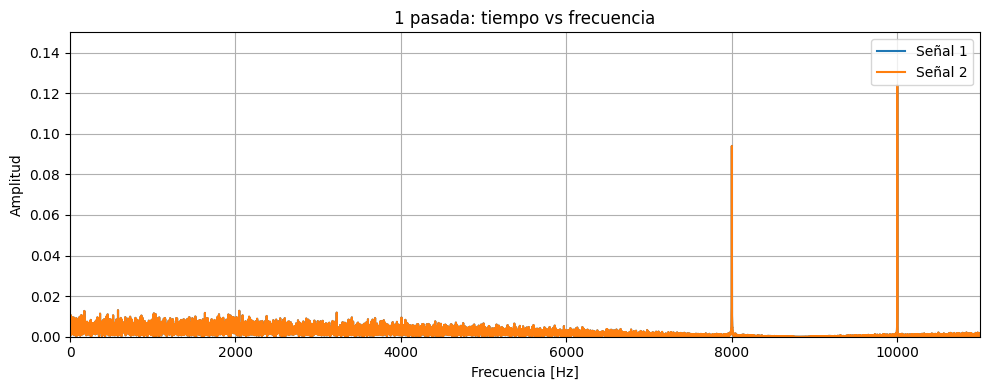

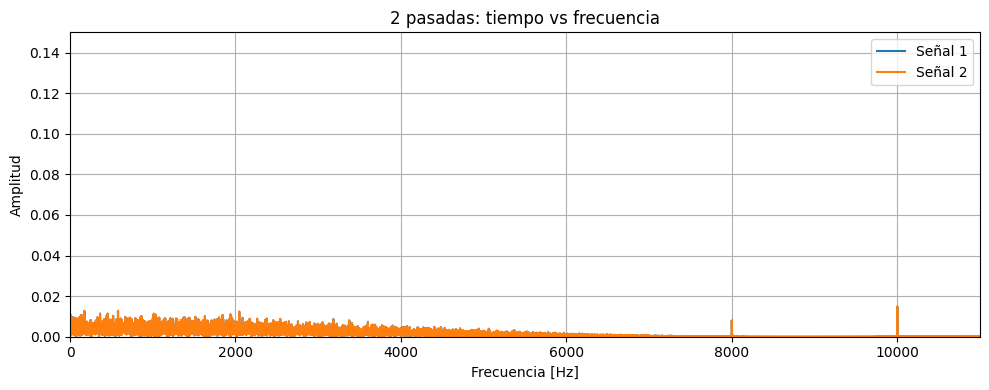

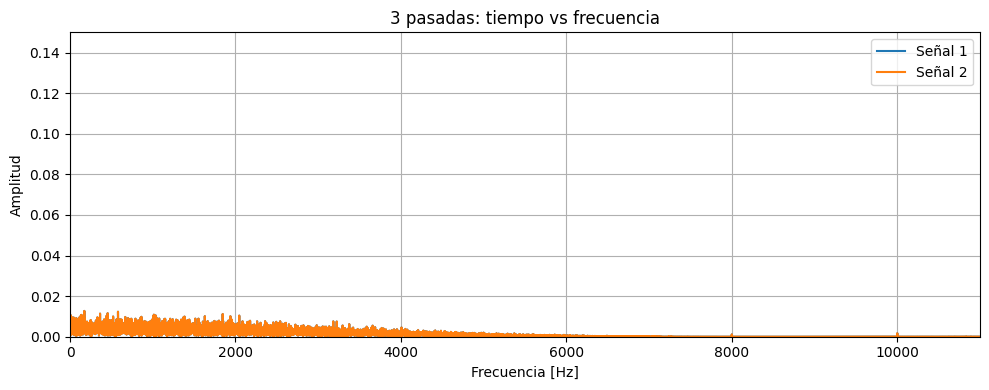

In [87]:
# Parámetros
fs = 44100       # frecuencia de muestreo: 1000 Hz
duracion = 1    # 1 segundo

senal = generar_suma_tonos(
    frecuencias=[8000, 10000],
    amplitudes=[1, 1],
    fs=fs,
    duracion=duracion
)

tonos_con_ruido, ruido = agregar_ruido_blanco(senal, amplitud=0.5)


# Se calculan los filtrados
y_1p_tiempo = filtrar_convolucion(tonos_con_ruido, h_1p)
y_2p_tiempo = filtrar_convolucion(tonos_con_ruido, h_2p)
y_3p_tiempo = filtrar_convolucion(tonos_con_ruido, h_3p)

y_1p_freq   = filtrar_frecuencia(tonos_con_ruido, h_1p)
y_2p_freq   = filtrar_frecuencia(tonos_con_ruido, h_2p)
y_3p_freq   = filtrar_frecuencia(tonos_con_ruido, h_3p)

graficar_espectros([y_1p_tiempo, y_1p_freq], fs=fs, titulo="1 pasada: tiempo vs frecuencia", xlim=(0, 11000), ylim=(0,0.15))
graficar_espectros([y_2p_tiempo, y_2p_freq], fs=fs, titulo="2 pasadas: tiempo vs frecuencia", xlim=(0, 11000), ylim=(0,0.15))
graficar_espectros([y_3p_tiempo, y_3p_freq], fs=fs, titulo="3 pasadas: tiempo vs frecuencia", xlim=(0, 11000), ylim=(0,0.15))



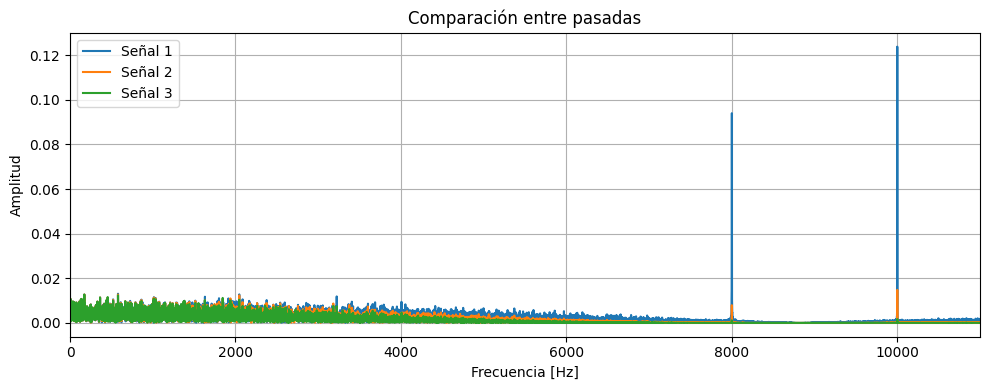

In [88]:
# Comparación entre pasadas: efecto en el espectro
graficar_espectros(
    [y_1p_tiempo, y_2p_tiempo, y_3p_tiempo],
    fs=fs, titulo="Comparación entre pasadas", xlim=(0, 11000)
)

#### Efecto de las pasadas sobre el espectro

Al comparar los espectros de las señales filtradas con 1, 2 y 3 pasadas se observa que:
- Con más pasadas, la atenuación de las frecuencias altas es progresivamente mayor.
- En la primera pasada, la amplitud de los tonos baja, pero no tanto ya que están cayendo en un lóbulo secundario, como se puede ver en el gráfico que muestra el módulo de dicho filtro.
- Como 10 kHz aparece en un pico más alto de un lóbulo secundario, entonces tiene sentido que tenga más nivel que 8 kHz.
- El piso de ruido en altas se reduce con cada pasada adicional, lo que confirma el mayor efecto suavizante de los filtros con múltiples pasadas. Además es posible notar la envolvente de la sinc en el ruido con una pasada.


### Comparación de método de filtrado
En cuanto a resultados, los dos dan exactamente lo mismo, lo cual tiene sentido aplicando propiedades de la DFT para la convolución. La diferencia yace en el tiempo de cómputo:

Para el **filtro corto** (h_3p, M = 13 coeficientes), la convolución temporal realiza:

$$N \cdot M = 1000 \cdot 13 = 13.000 \text{ operaciones}$$

mientras que el método en frecuencia requiere del orden de:

$$N \cdot \log_2(N) \approx 1000 \cdot 10 = 10.000 \text{ operaciones}$$

En este caso ambos métodos tienen costos similares, pero el overhead fijo de la FFT hace que el método temporal resulte más rápido.

---

Para el **filtro largo** (FIR, M = 1457 coeficientes), la convolución temporal escala a:

$$N \cdot M = 1000 \cdot 1457 = 1.457.000 \text{ operaciones}$$

mientras que el costo del método en frecuencia **permanece igual**, independientemente de M:

$$N \cdot \log_2(N) \approx 10.000 \text{ operaciones}$$

La diferencia es de **dos órdenes de magnitud**, y el método en frecuencia resulta ampliamente superior.




In [89]:

t0 = time.perf_counter()
filtrar_convolucion(tonos_con_ruido, h_3p)
t_conv_corto = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
filtrar_frecuencia(tonos_con_ruido, h_3p)
t_freq_corto = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
filtrar_convolucion(tonos_con_ruido, h_fir)
t_conv_largo = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
filtrar_frecuencia(tonos_con_ruido, h_fir)
t_freq_largo = (time.perf_counter() - t0) * 1000

print(f"{'':32} {'Temporal':>12} {'Frecuencia':>12}")
print(f"{'Filtro corto (h_3p,  13 coef)':32} {t_conv_corto:>10.3f}ms {t_freq_corto:>10.3f}ms")
print(f"{'Filtro largo (FIR, 1457 coef)':32} {t_conv_largo:>10.3f}ms {t_freq_largo:>10.3f}ms")

                                     Temporal   Frecuencia
Filtro corto (h_3p,  13 coef)         0.311ms      8.971ms
Filtro largo (FIR, 1457 coef)        28.415ms     10.736ms


---

 **Conclusión:** la ventaja del método en frecuencia crece con la longitud de la señal y el filtro. Su complejidad es **O(N · log₂N)** y no depende de M, mientras que la convolución directa tiene complejidad **O(N · M)**.

### 6. Filtrado de señal musical (con media móvil)

Se procede a generar la señal musical con tonos agudos para estudiar el comportamiento

In [90]:
fs = 44100
notas = [8000, 9500, 11000, 8000]  # Do6, Mi6, Sol6 — una octava más arriba
duraciones = [0.2, 0.2, 0.2, .2]

melodia_alta = generar_melodia(notas, duraciones, fs)
senal_con_ruido, _ = agregar_ruido_blanco(melodia_alta, amplitud=0.2)
generate_wav(senal_con_ruido, "melodia_alta_ruido_0.2.wav", fs)



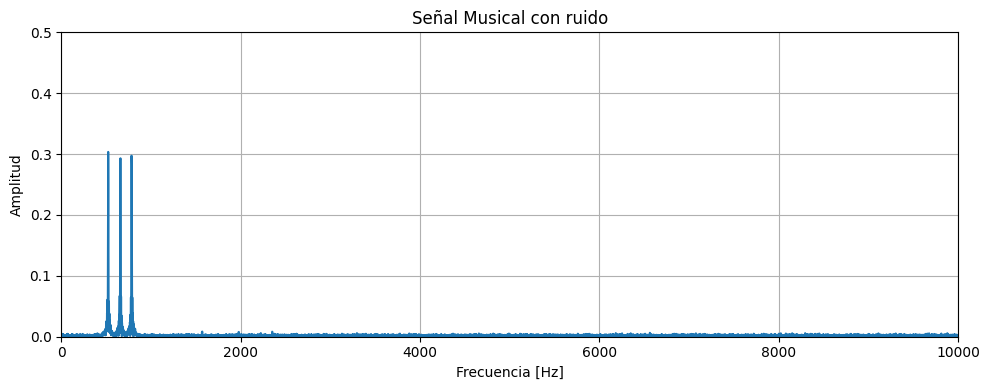

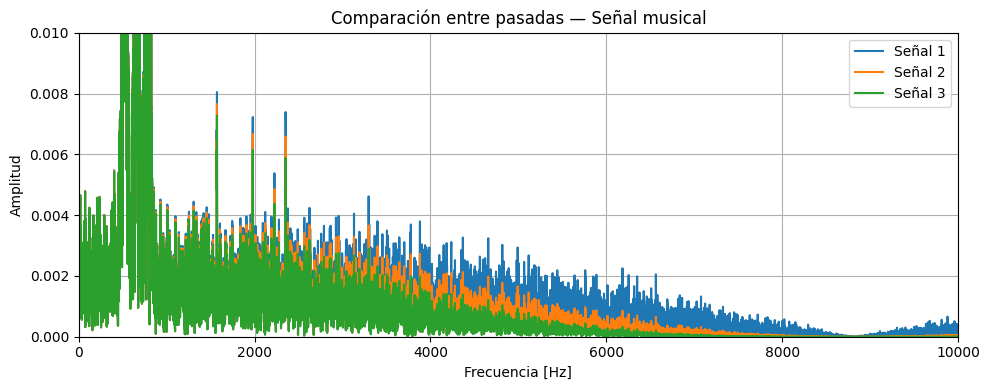

In [91]:

fs, senal_con_ruido = cargar_wav("melodia_ruido_0.2.wav")

y_1p_musical = filtrar_frecuencia(senal_con_ruido, h_1p)[:len(senal_con_ruido)]
y_2p_musical = filtrar_frecuencia(senal_con_ruido, h_2p)[:len(senal_con_ruido)]
y_3p_musical = filtrar_frecuencia(senal_con_ruido, h_3p)[:len(senal_con_ruido)]

# Comparación entre pasadas — señal musical

graficar_espectros(
    [senal_con_ruido],
    fs=44100, titulo="Señal Musical con ruido", xlim=(0, 10000), ylim=(0,.5)
)

graficar_espectros(
    [y_1p_musical, y_2p_musical, y_3p_musical],
    fs=44100, titulo="Comparación entre pasadas — Señal musical", xlim=(0, 10000), ylim=(0,.01)

)
    

### Observación: comparación entre tonos y señal musical

En ambos casos se aplica el mismo filtro de media móvil (pasa-bajos con frecuencia de corte baja relativa a fs), pero el efecto es opuesto según dónde se ubican las componentes espectrales de cada señal:

- **Tonos (8000 y 10000 Hz):** las componentes se encuentran en la zona de alta frecuencia, donde el filtro media móvil atenúa fuertemente. Con más pasadas, la atenuación crece y los picos prácticamente desaparecen. El filtro actúa sobre la señal útil.

- **Señal musical (523, 659, 783 Hz):** las notas se ubican en la zona de baja frecuencia, dentro del lóbulo principal del filtro. El filtro apenas las modifica con 1 pasada, y con 2 o 3 pasadas la atenuación sigue siendo muy leve. La señal útil queda prácticamente intacta, pero el ruido se ve reducido pasada la frecuencia del corte, y es posible observar la envolvente de la respuesta en freuencia del filtro media movil en cada pasada en el ruido añadido.

### 7. Filtrado peine

Dado que se verificó experimentalmente que el filtrado mediante convolución directa en el dominio temporal y mediante multiplicación espectral en frecuencia producen resultados equivalentes, a partir de este punto se utilizará el método basado en FFT para realizar el filtrado.

Se genera la suma de tonos pertinente, y se carga la señal musical:

In [ ]:
# Parámetros
fs = 44100       # frecuencia de muestreo: 1000 Hz
duracion = 1    # 1 segundo

senal = generar_suma_tonos(
    frecuencias=[1000, 4000, 10000],
    amplitudes=[1, 1, 1],
    fs=fs,
    duracion=duracion
)

tonos_con_ruido, ruido = agregar_ruido_blanco(senal, amplitud=0.5)

fs, senal_con_ruido = cargar_wav("melodia_ruido_0.2.wav")



Se procede a aplicar el filtrado a ambas señales:

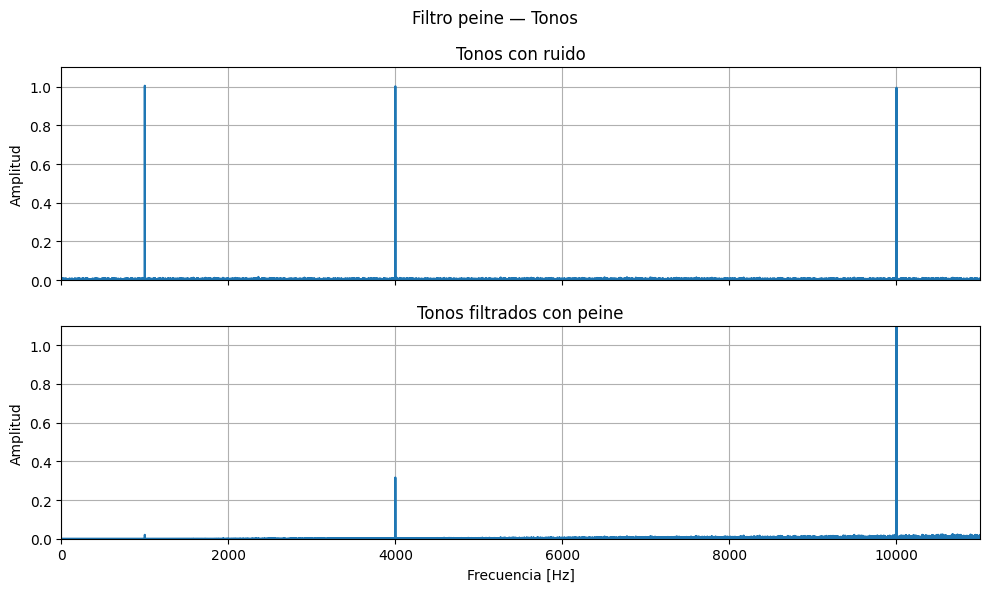

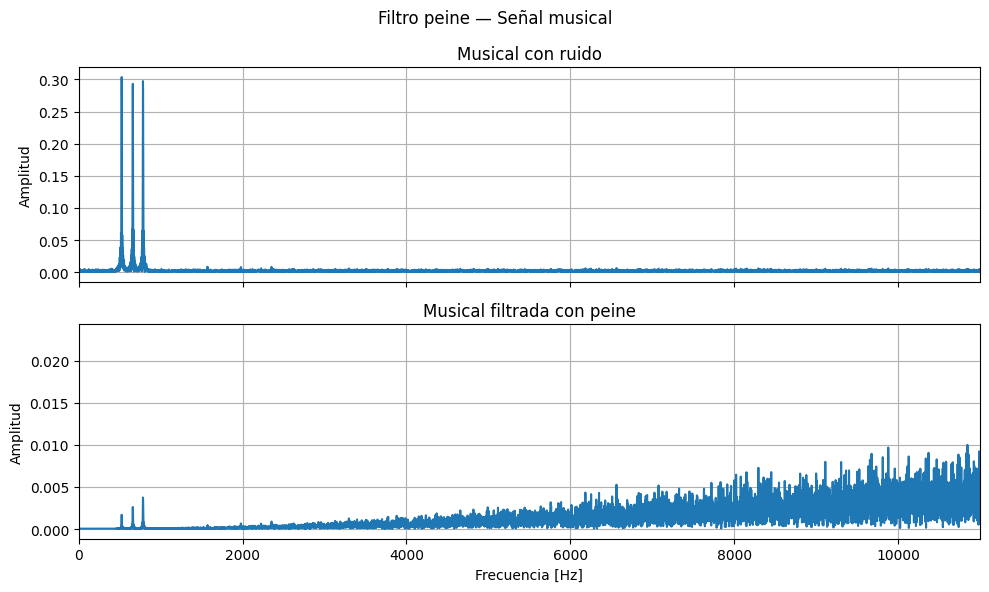

In [93]:
# Tonos (fs=1000)
y_peine_freq = filtrar_frecuencia(tonos_con_ruido, h_peine)[:len(tonos_con_ruido)]
y_peine_freq2 = filtrar_frecuencia(senal_con_ruido, h_peine)[:len(senal_con_ruido)]

graficar_espectros(
    [tonos_con_ruido, y_peine_freq],
    fs=44100, titulo="Filtro peine — Tonos", subplots=True, xlim=(0, 11000), ylim=(0,1.1),
    titles=["Tonos con ruido", "Tonos filtrados con peine"]
)

# Señal musical (fs=44100)
graficar_espectros(
    [senal_con_ruido, y_peine_freq2],
    fs=44100, titulo="Filtro peine — Señal musical", subplots=True, xlim=(0, 11000),
    titles=["Musical con ruido", "Musical filtrada con peine"]
)

### Observación:

**Efecto del filtrado:** el filtro peine h=[1,−2,1] modifica las señales de manera muy distinta al filtro media móvil. En lugar de suavizarlas, resalta las variaciones rápidas y los cambios bruscos entre muestras consecutivas, el comportamiento de un pasa altos. 

### 8. Filtrado de la señal con ruido (FIR)

Se carga el filtro diseñado mediante la ventana Hamming y se lo aplica a ambas señales:

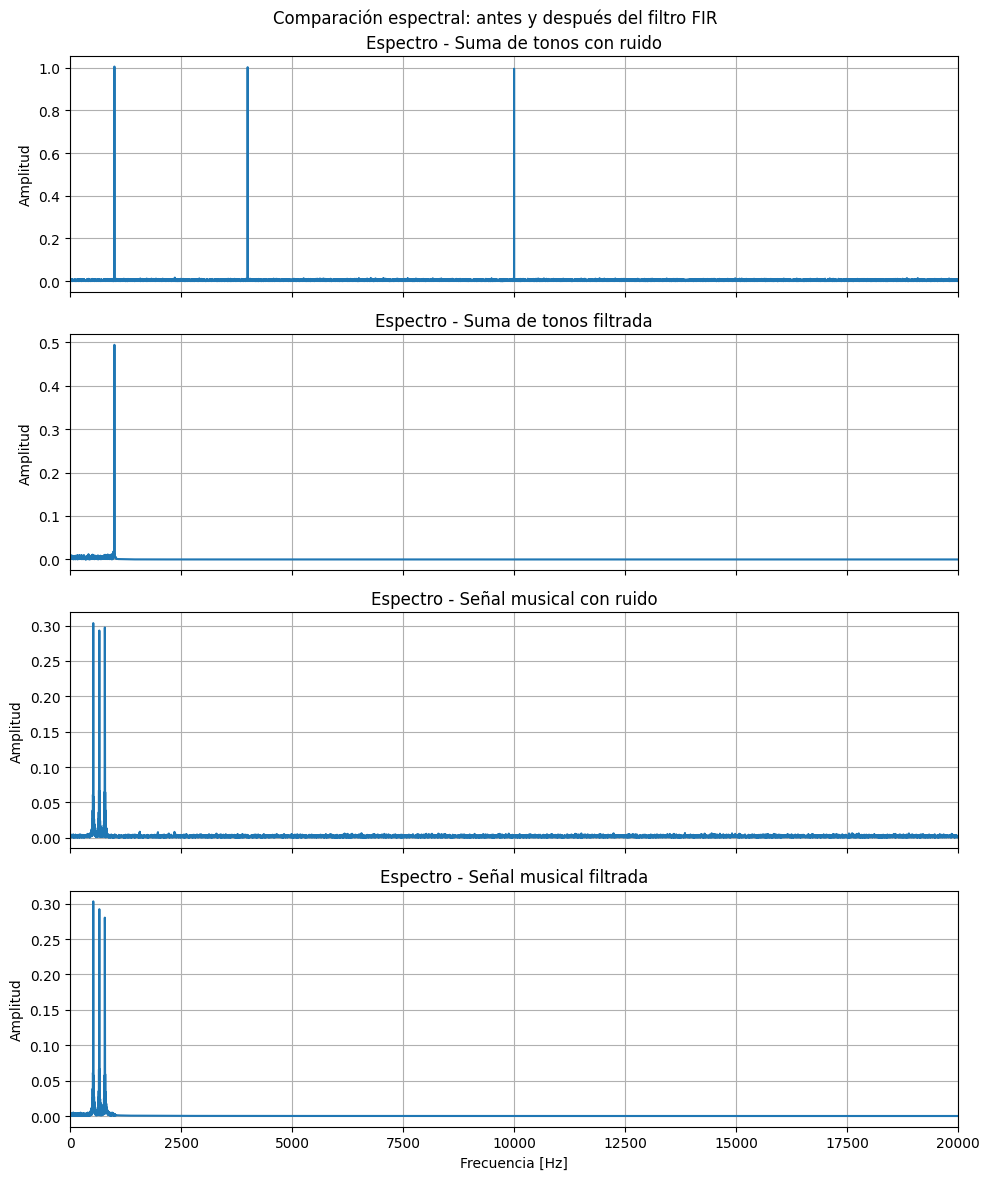

In [100]:
fir = cargar_filtro_fir("fir_hamming_1000Hz.npy")

# Filtrado
y_fir_freq = filtrar_frecuencia(
    tonos_con_ruido,
    fir
)[:len(tonos_con_ruido)]

y_fir_freq2 = filtrar_frecuencia(
    senal_con_ruido,
    fir
)[:len(senal_con_ruido)]

# Graficamos
graficar_espectros(
    [ 
        tonos_con_ruido,
        y_fir_freq,
        senal_con_ruido,
        y_fir_freq2
    ],
    fs=fs,
    titulo="Comparación espectral: antes y después del filtro FIR",
    subplots=True,
    xlim=(0, 20000),
    titles=[
        "Espectro - Suma de tonos con ruido",
        "Espectro - Suma de tonos filtrada",
        "Espectro - Señal musical con ruido",
        "Espectro - Señal musical filtrada"
    ]
)


### Observación

En el análisis espectral se observó que el filtro conserva las componentes principales de baja frecuencia presentes en las señales de entrada y atenúa componentes distribuidas sobre una banda más amplia, comportamiento consistente con un filtro FIR pasa-bajos diseñado mediante ventana de Hamming. La reducción del contenido fuera de banda resulta más evidente en señales contaminadas con ruido, donde el filtrado mejora la relación entre componentes útiles y no deseadas sin modificar significativamente la estructura espectral dominante.

### 9. Variación de parámetros de filtros

Se procede a variar los parámetros de los filtros de media móvil y del filtro peine para estudiar el comportamiento de ellos.

### Media móvil

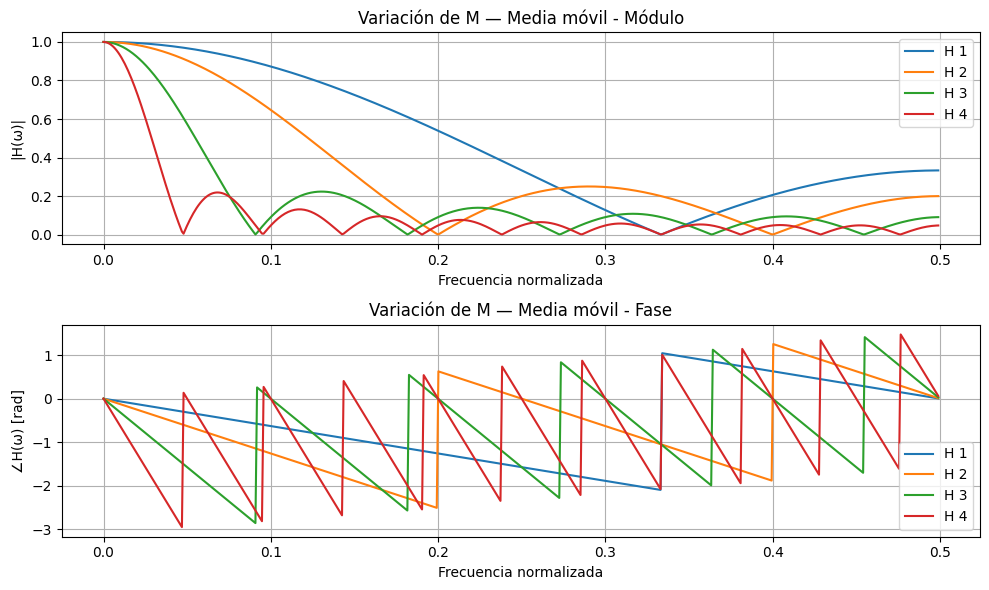

In [ ]:
M_values = [3, 5, 11, 21]

N = 1024
impulso = np.zeros(N)
impulso[0] = 1

H_lista = []
freqs_lista = []

for M in M_values:

    h = filtro_media_movil(M)

    y = filtrar_convolucion(
        impulso,
        h
    )[:N]

    H, freqs = calcular_H(
        impulso,
        y
    )

    H_lista.append(H)
    freqs_lista.append(freqs)

graficar_H(
    H_lista,
    freqs_lista,
    titulo="Variación de M — Media móvil"
)

### Peine

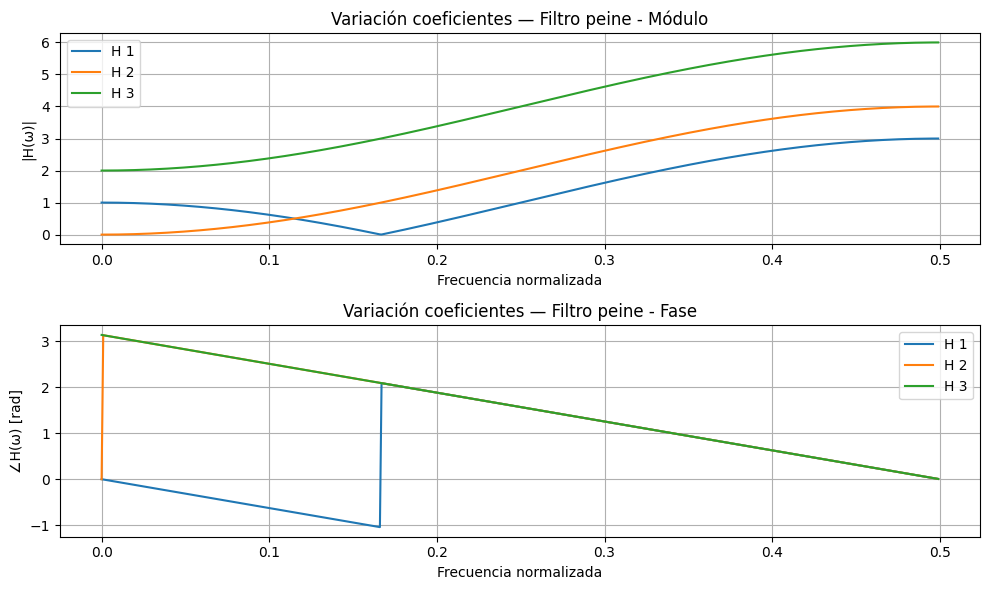

In [ ]:

coeficientes = [
    [1, -1, 1],
    [1, -2, 1],
    [1, -4, 1]
]

H_lista = []
freqs_lista = []

for b0, b1, b2 in coeficientes:

    h = filtro_peine(
        b0,
        b1,
        b2
    )

    y = filtrar_convolucion(
        impulso,
        h
    )[:N]

    H, freqs = calcular_H(
        impulso,
        y
    )

    H_lista.append(H)
    freqs_lista.append(freqs)

graficar_H(
    H_lista,
    freqs_lista,
    titulo="Variación coeficientes — Filtro peine"
)

Se observa que al aumentar M en el filtro de media móvil, el lóbulo principal se estrecha y aumenta la atenuación fuera de la banda de paso, verificando un incremento de selectividad.

En el filtro peine se observa que la modificación de coeficientes altera la profundidad y distribución de máximos y mínimos espectrales.

### 10. Truncado de los coeficientes FIR

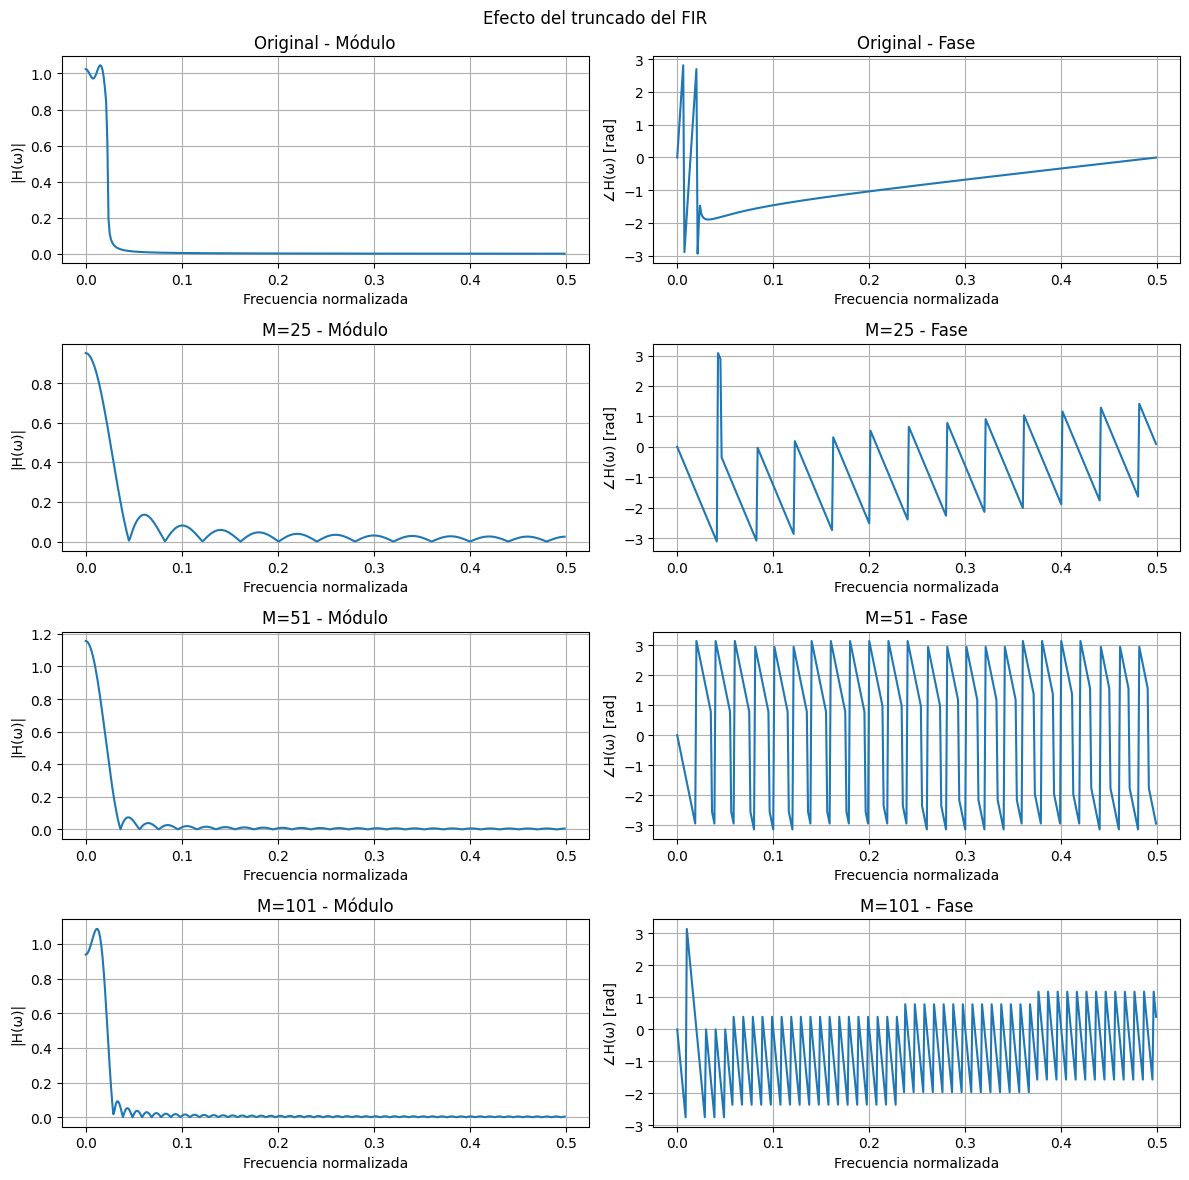

In [98]:
M_values = [25, 51, 101]

filtros = []

for M in M_values:

    h = truncar_fir(
        fir,
        M
    )

    filtros.append(h)

N = 800

impulso = np.zeros(N)
impulso[0] = 1

H_lista = []
freqs_lista = []

# FIR original
y = filtrar_convolucion(
    impulso,
    fir
)[:N]

H, freqs = calcular_H(
    impulso,
    y
)

H_lista.append(H)
freqs_lista.append(freqs)

# Truncados
for h in filtros:

    y = filtrar_convolucion(
        impulso,
        h
    )[:N]

    H, _ = calcular_H(
        impulso,
        y
    )

    H_lista.append(H)
    freqs_lista.append(freqs)

graficar_H(
    H_lista,
    freqs_lista,
    titulo="Efecto del truncado del FIR",
    subplots=True,
    titles=[
        "Original",
        "M=25",
        "M=51",
        "M=101"
    ]
)

### 11. IDENTIFICACIÓN DE SISTEMA

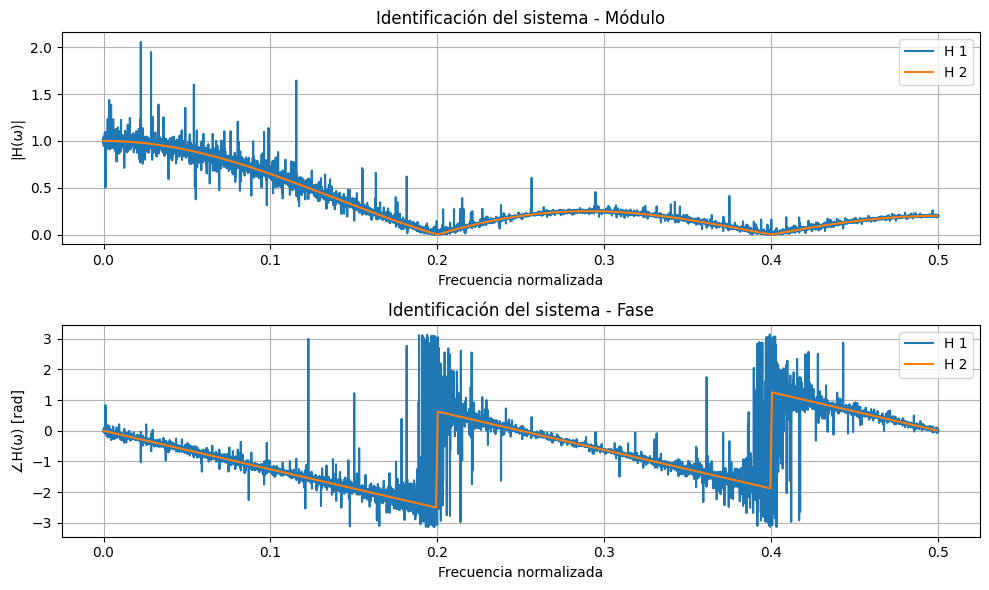

In [95]:
# Sistema a identificar
sistema_a_identificar = filtro_media_movil(5)

entrada = tonos_con_ruido

# Salida del sistema
salida = filtrar_convolucion(
    entrada,
    sistema_a_identificar
)[:len(entrada)]

# H identificada
H_identificada, freqs_id = calcular_H(
    entrada,
    salida
)

# H teórica
impulso = np.zeros(1024)
impulso[0] = 1

salida_teorica = filtrar_convolucion(
    impulso,
    sistema_a_identificar
)[:1024]

H_teorica, freqs_teo = calcular_H(
    impulso,
    salida_teorica
)

# Graficar usando función propia
graficar_H(
    [H_identificada, H_teorica],
    [freqs_id, freqs_teo],
    titulo="Identificación del sistema",
    titles=[
        "H(ω) identificada",
        "H(ω) teórica"
    ]
)